# Volatility forecasting with path signatures

One experiment, run end to end: for each horizon (5 min, 1 hour, 1 / 7 / 30 day) every model is fit on the **same purged expanding-window walk-forward folds**, and every table and figure below is generated from the saved results.

- The heavy work lives in `experiment.py` (runner) and `reporting.py` (tables/figures); this notebook is only config, run, and display.
- **Purge:** the target is realized volatility over the next *h*, so training rows whose label window reaches the first test time are dropped from each fold.
- Each horizon runs in its own Python process and finished horizons are skipped on re-run, so a crash cannot take the kernel down and can be resumed.
- Results are written to `results/<run>/<horizon>/`. Re-run only the display cells to regenerate figures.

In [1]:
import logging
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import experiment as ex
import reporting as rp

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s", datefmt="%H:%M:%S")
pd.set_option("display.float_format", "{:.6g}".format)

## 1. Configuration

In [2]:
QUICK = False  # True: small, fast run to check that everything works

cfg = ex.ExperimentConfig(
    horizons=("5m", "1h", "1d", "7d", "30d"),
    n_folds=3,                       # expanding-window folds (+1 train-only block)
    binance_start="2026-07-01",      # ~2.5 months of ticks, streamed one day at a time
    binance_end="2026-09-15",
    yahoo_start="2015-01-01",        # full Yahoo history, no cap
    target_rows={"5m": 4000, "1h": 4000, "1d": None, "7d": None, "30d": None},
    torch_epochs=200,
    run_ablations=True,
    output_dir="results/main",
)
if QUICK:
    cfg = cfg.quick()
cfg

ExperimentConfig(horizons=('5m', '1h', '1d', '7d', '30d'), n_folds=3, min_train_rows=50, symbol='BTCUSDT', binance_start='2026-07-01', binance_end='2026-09-15', ticker='BTC-USD', yahoo_start='2015-01-01', yahoo_end=None, target_rows={'5m': 4000, '1h': 4000, '1d': None, '7d': None, '30d': None}, models=None, torch_epochs=200, weight_decay={'5m': 0.0001, '1h': 0.0001, '1d': 0.0001, '7d': 0.0005, '30d': 0.001}, lstm_sub_window={'5m': '30min', '1h': '6h', '1d': '5D', '7d': '5D', '30d': '5D'}, xgb_estimators=500, seed=42, run_ablations=True, ablation_models=('Ridge | signature',), data_dir='data', cache_dir='cache', output_dir='results/main', force_download=False, resume=True)

## 2. Run

Binance days are downloaded once, reduced to 5-second and 1-minute bars, and cached under `data/bars/`; signature features are cached under `cache/`. Safe to re-run: completed horizons are skipped (delete `results/<run>/<horizon>/` to redo one).

In [3]:
ex.run_all(cfg, subprocess_per_horizon=True)

17:47:17 | [1/77] Downloading BTCUSDT 2026-07-01
17:47:23 | [2/77] Downloading BTCUSDT 2026-07-02
17:47:29 | [3/77] Downloading BTCUSDT 2026-07-03
17:47:33 | [4/77] Downloading BTCUSDT 2026-07-04
17:47:37 | [5/77] Downloading BTCUSDT 2026-07-05
17:47:40 | [6/77] Downloading BTCUSDT 2026-07-06
17:47:46 | [7/77] Downloading BTCUSDT 2026-07-07
17:47:51 | [8/77] Downloading BTCUSDT 2026-07-08
17:47:56 | [9/77] Downloading BTCUSDT 2026-07-09
17:48:01 | [10/77] Downloading BTCUSDT 2026-07-10
17:48:06 | [11/77] Downloading BTCUSDT 2026-07-11
17:48:09 | [12/77] Downloading BTCUSDT 2026-07-12
17:48:12 | [13/77] Downloading BTCUSDT 2026-07-13
17:48:17 | [14/77] Downloading BTCUSDT 2026-07-14
17:48:22 | [15/77] Downloading BTCUSDT 2026-07-15
17:48:27 | [16/77] Downloading BTCUSDT 2026-07-16
17:48:31 | [17/77] Downloading BTCUSDT 2026-07-17
17:48:36 | [18/77] Downloading BTCUSDT 2026-07-18
17:48:39 | [19/77] Downloading BTCUSDT 2026-07-19
17:48:42 | [20/77] Downloading BTCUSDT 2026-07-20
17:48:47 

PosixPath('results/main')

## 3. Results

In [4]:
res = rp.load_results(cfg.output_dir)
pd.DataFrame(res.meta).T[["n_rows", "stride", "horizon_steps", "horizon_rows", "n_folds", "first_time", "last_time", "seconds"]]

,n_rows,stride,horizon_steps,horizon_rows,n_folds,first_time,last_time,seconds
1d,4262,1,1,1,3,2015-01-30 00:00:00+00:00,2026-09-30 00:00:00+00:00,116.6
1h,3907,28,60,3,3,2026-07-01 23:59:00+00:00,2026-09-15 22:47:00+00:00,119.2
30d,4233,1,30,30,3,2015-01-30 00:00:00+00:00,2026-09-01 00:00:00+00:00,116.8
5m,3992,333,60,1,3,2026-07-01 01:59:55+00:00,2026-09-15 23:50:10+00:00,467.7
7d,4256,1,7,7,3,2015-01-30 00:00:00+00:00,2026-09-24 00:00:00+00:00,117.5


### Model ranking per horizon

RMSE averaged over folds, with the fold-to-fold SD. `Pct_vs_Mean` / `Pct_vs_HAR` are % RMSE improvements over the no-information and HAR-RV-L forecasts.

In [5]:
summary = rp.summary_table(res)
display(summary.style.format({"Mean_RMSE": "{:.6g}", "Fold_SD": "{:.6g}", "Pct_vs_Mean": "{:.1f}", "Pct_vs_HAR": "{:.1f}"}))

,Horizon,Model,Mean_RMSE,Fold_SD,Pct_vs_Mean,Pct_vs_HAR,Rank
0,5 min,Ridge | stats+signature,0.000410624,8.09425e-05,33.0,12.3,1
1,5 min,Ridge | stats,0.000425312,7.18461e-05,30.6,9.2,2
2,5 min,Ridge | signature,0.000442751,9.40759e-05,27.7,5.5,3
3,5 min,HAR-RV-L,0.000468459,9.46364e-05,23.5,0.0,4
4,5 min,XGBoost | signature,0.000527964,0.000131141,13.8,-12.7,5
5,5 min,XGBoost | stats,0.00053691,0.000130077,12.4,-14.6,6
6,5 min,MLP | stats+signature,0.000597502,0.000172837,2.5,-27.5,7
7,5 min,MLP | stats,0.000607159,0.000160251,0.9,-29.6,8
8,5 min,Mean,0.000612751,0.000150514,0.0,-30.8,9
9,5 min,Signature LSTM,0.000718988,0.000453114,-17.3,-53.5,10


### Diebold-Mariano tests (pooled out-of-sample)

A low p-value means that model is significantly different from the reference, not just numerically so. The test lag is the horizon length in forecast rows, since overlapping targets autocorrelate the errors.

In [6]:
for hk in res.meta:
    print(f"\n{ex.HORIZON_LABELS[hk]}")
    display(rp.dm_table(res, hk).style.format(
        {"Pooled_RMSE": "{:.6g}", "DM_vs_best": "{:.2f}", "p_vs_best": "{:.3g}", "DM_vs_HAR": "{:.2f}", "p_vs_HAR": "{:.3g}"}))


1 day


,Model,Pooled_RMSE,Best,DM_vs_best,p_vs_best,DM_vs_HAR,p_vs_HAR
0,Ridge | stats+signature,0.0152027,True,nan,nan,-3.45,0.000554
1,Ridge | signature,0.0152237,False,2.25,0.0246,-3.36,0.000787
2,XGBoost | signature,0.0154029,False,1.17,0.242,-3.04,0.00236
3,Ridge | stats,0.0163964,False,8.47,0,-0.43,0.664
4,Signature LSTM,0.0165594,False,5.07,4e-07,-0.06,0.949
5,HAR-RV-L,0.016591,False,3.45,0.000554,nan,nan
6,"GARCH(1,1)",0.018416,False,8.06,8.88e-16,7.43,1.12e-13
7,XGBoost | stats,0.0184282,False,14.54,0,4.70,2.63e-06
8,MLP | stats+signature,0.0187602,False,5.97,2.32e-09,4.20,2.64e-05
9,Mean,0.0189753,False,10.08,0,3.83,0.000129



1 hour


,Model,Pooled_RMSE,Best,DM_vs_best,p_vs_best,DM_vs_HAR,p_vs_HAR
0,HAR-RV-L,0.0015319,True,nan,nan,nan,nan
1,Ridge | stats,0.00175233,False,5.08,3.74e-07,5.08,3.74e-07
2,Ridge | stats+signature,0.00178721,False,5.62,1.94e-08,5.62,1.94e-08
3,XGBoost | signature,0.00185423,False,6.60,4.19e-11,6.60,4.19e-11
4,Ridge | signature,0.00186164,False,6.77,1.31e-11,6.77,1.31e-11
5,XGBoost | stats,0.00193099,False,7.28,3.4e-13,7.28,3.4e-13
6,Signature LSTM,0.00204954,False,10.31,0,10.31,0
7,MLP | stats+signature,0.0021104,False,9.59,0,9.59,0
8,Mean,0.00211582,False,9.64,0,9.64,0
9,MLP | stats,0.00212849,False,10.23,0,10.23,0



30 day


,Model,Pooled_RMSE,Best,DM_vs_best,p_vs_best,DM_vs_HAR,p_vs_HAR
0,Ridge | stats+signature,0.0585216,True,nan,nan,-2.54,0.011
1,Ridge | signature,0.058928,False,1.10,0.272,-2.24,0.0253
2,Ridge | stats,0.0658386,False,2.72,0.00659,-0.04,0.969
3,HAR-RV-L,0.0659608,False,2.54,0.011,nan,nan
4,Signature LSTM,0.0661122,False,2.97,0.00302,0.04,0.966
5,XGBoost | signature,0.0680081,False,3.65,0.000259,0.47,0.638
6,Mean,0.070533,False,2.71,0.00673,0.85,0.395
7,MLP | stats+signature,0.0808725,False,4.40,1.06e-05,3.37,0.000754
8,"GARCH(1,1)",0.0957687,False,4.54,5.53e-06,4.29,1.75e-05
9,XGBoost | stats,0.111261,False,7.18,6.87e-13,6.92,4.59e-12



5 min


,Model,Pooled_RMSE,Best,DM_vs_best,p_vs_best,DM_vs_HAR,p_vs_HAR
0,Ridge | stats+signature,0.000415908,True,nan,nan,-2.87,0.00411
1,Ridge | stats,0.000429338,False,0.62,0.535,-2.25,0.0245
2,Ridge | signature,0.000449364,False,1.58,0.113,-1.29,0.199
3,HAR-RV-L,0.000474789,False,2.87,0.00411,nan,nan
4,XGBoost | signature,0.000538712,False,6.41,1.41e-10,3.18,0.0015
5,XGBoost | stats,0.000547314,False,6.93,4.34e-12,3.57,0.000355
6,MLP | stats+signature,0.000613941,False,11.16,0,6.67,2.48e-11
7,MLP | stats,0.000621098,False,11.64,0,7.04,1.92e-12
8,Mean,0.000624953,False,11.91,0,6.98,3.01e-12
9,Signature LSTM,0.000808591,False,17.49,0,13.41,0



7 day


,Model,Pooled_RMSE,Best,DM_vs_best,p_vs_best,DM_vs_HAR,p_vs_HAR
0,Ridge | signature,0.0316467,True,nan,nan,-4.79,1.66e-06
1,Ridge | stats+signature,0.0321348,False,0.62,0.537,-3.48,0.000511
2,XGBoost | signature,0.0344462,False,3.08,0.00205,-1.27,0.204
3,Signature LSTM,0.0346379,False,4.11,4.02e-05,-1.20,0.232
4,MLP | stats+signature,0.0346779,False,2.92,0.0035,-1.02,0.307
5,Ridge | stats,0.0354719,False,4.27,1.91e-05,-0.34,0.735
6,HAR-RV-L,0.0358338,False,4.79,1.66e-06,nan,nan
7,Mean,0.0405928,False,4.84,1.3e-06,2.55,0.0107
8,"GARCH(1,1)",0.0420332,False,5.66,1.51e-08,4.57,4.93e-06
9,XGBoost | stats,0.0517685,False,11.57,0,10.66,0


## 4. Figures

### Improvement over the mean forecast

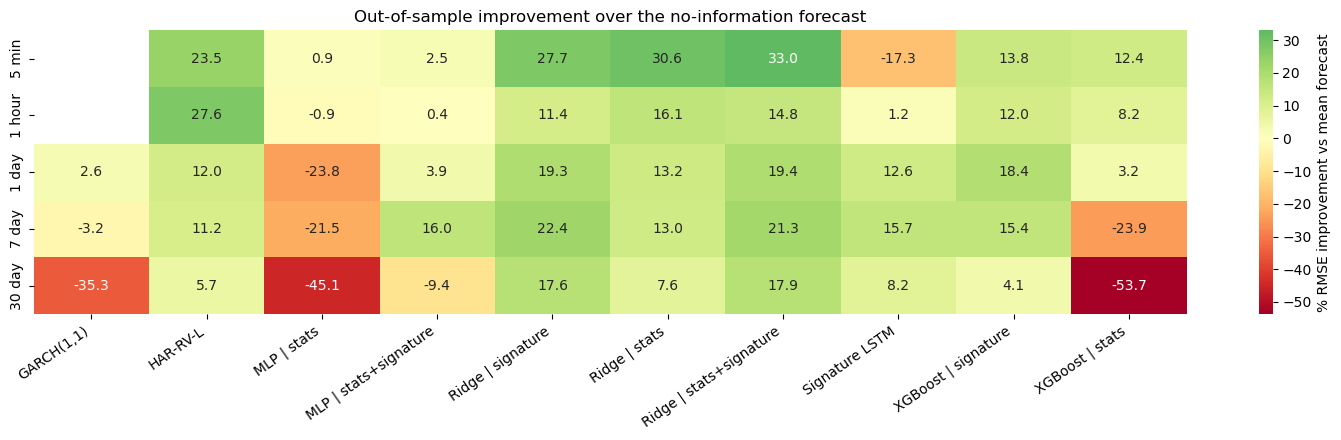

In [7]:
rp.plot_relative_heatmap(res); plt.show()

### Fold stability

A model is more convincing if it beats the mean in every fold, not just on average. Values below 1 beat the mean.

/Users/mihikaghaisas/miniforge3/envs/test1/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


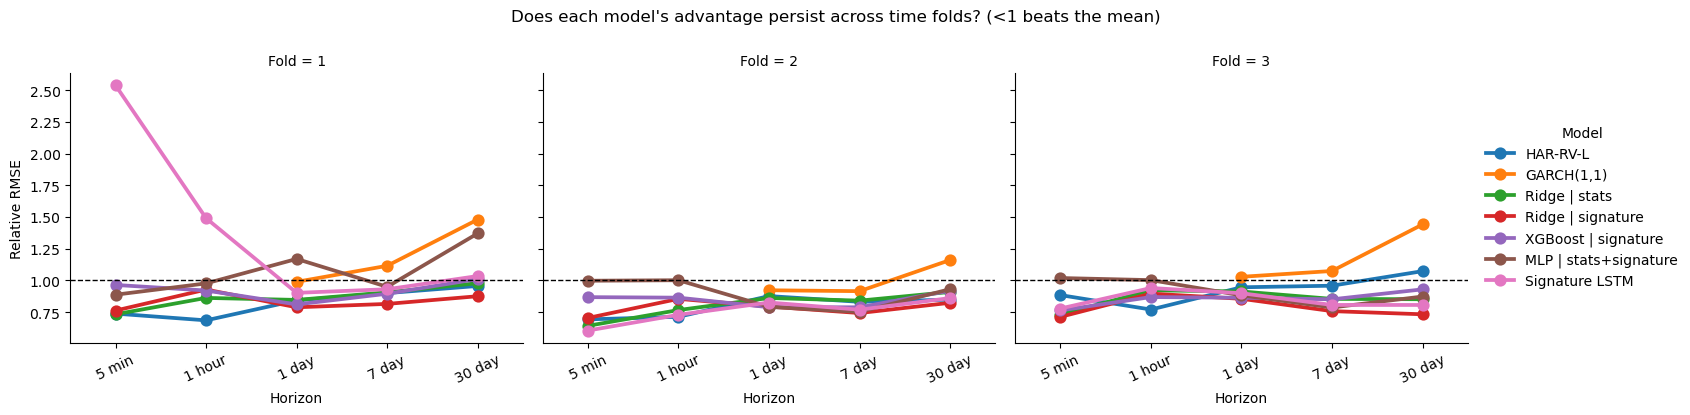

In [8]:
rp.plot_fold_stability(res); plt.show()

### Actual vs predicted volatility

Best model (lowest fold-mean RMSE) against HAR-RV-L.

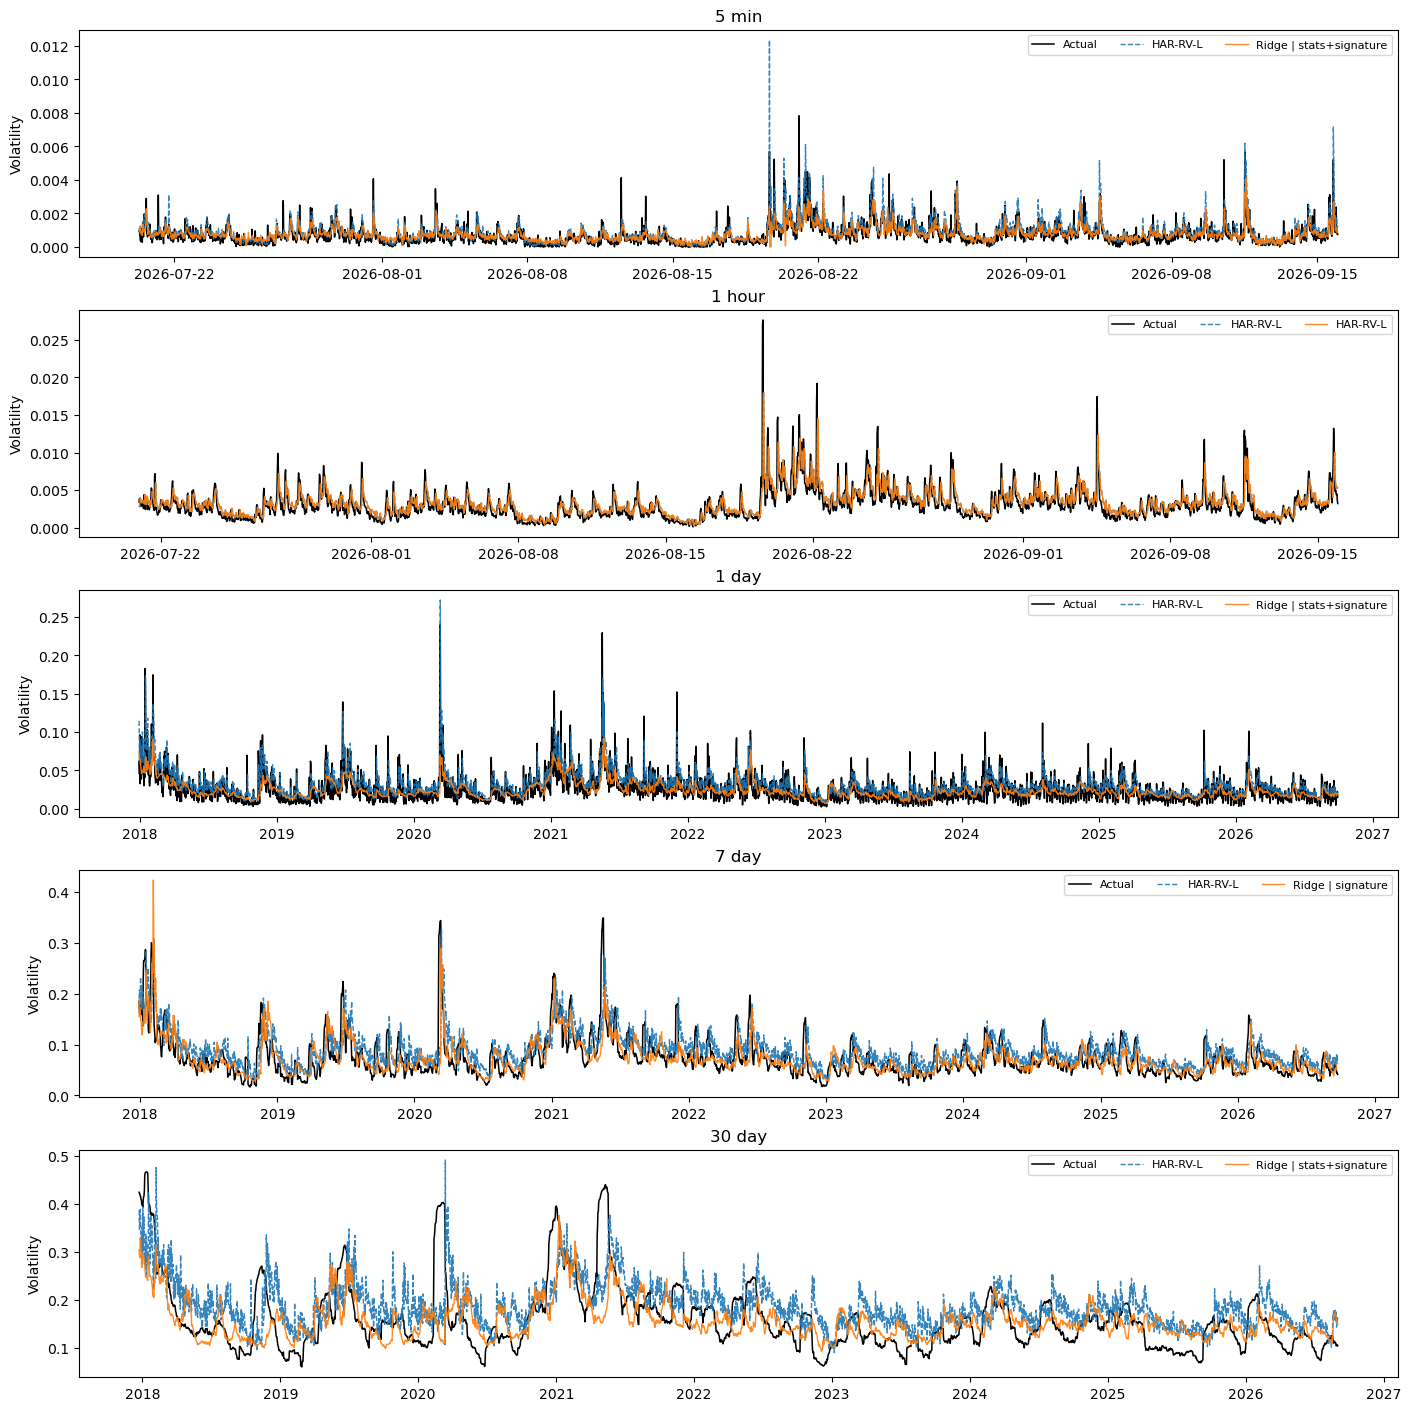

In [9]:
rp.plot_predictions(res); plt.show()

### When does the best model gain or lose against HAR?

Cumulative `HAR squared error - best-model squared error`; rising means the model is adding value.

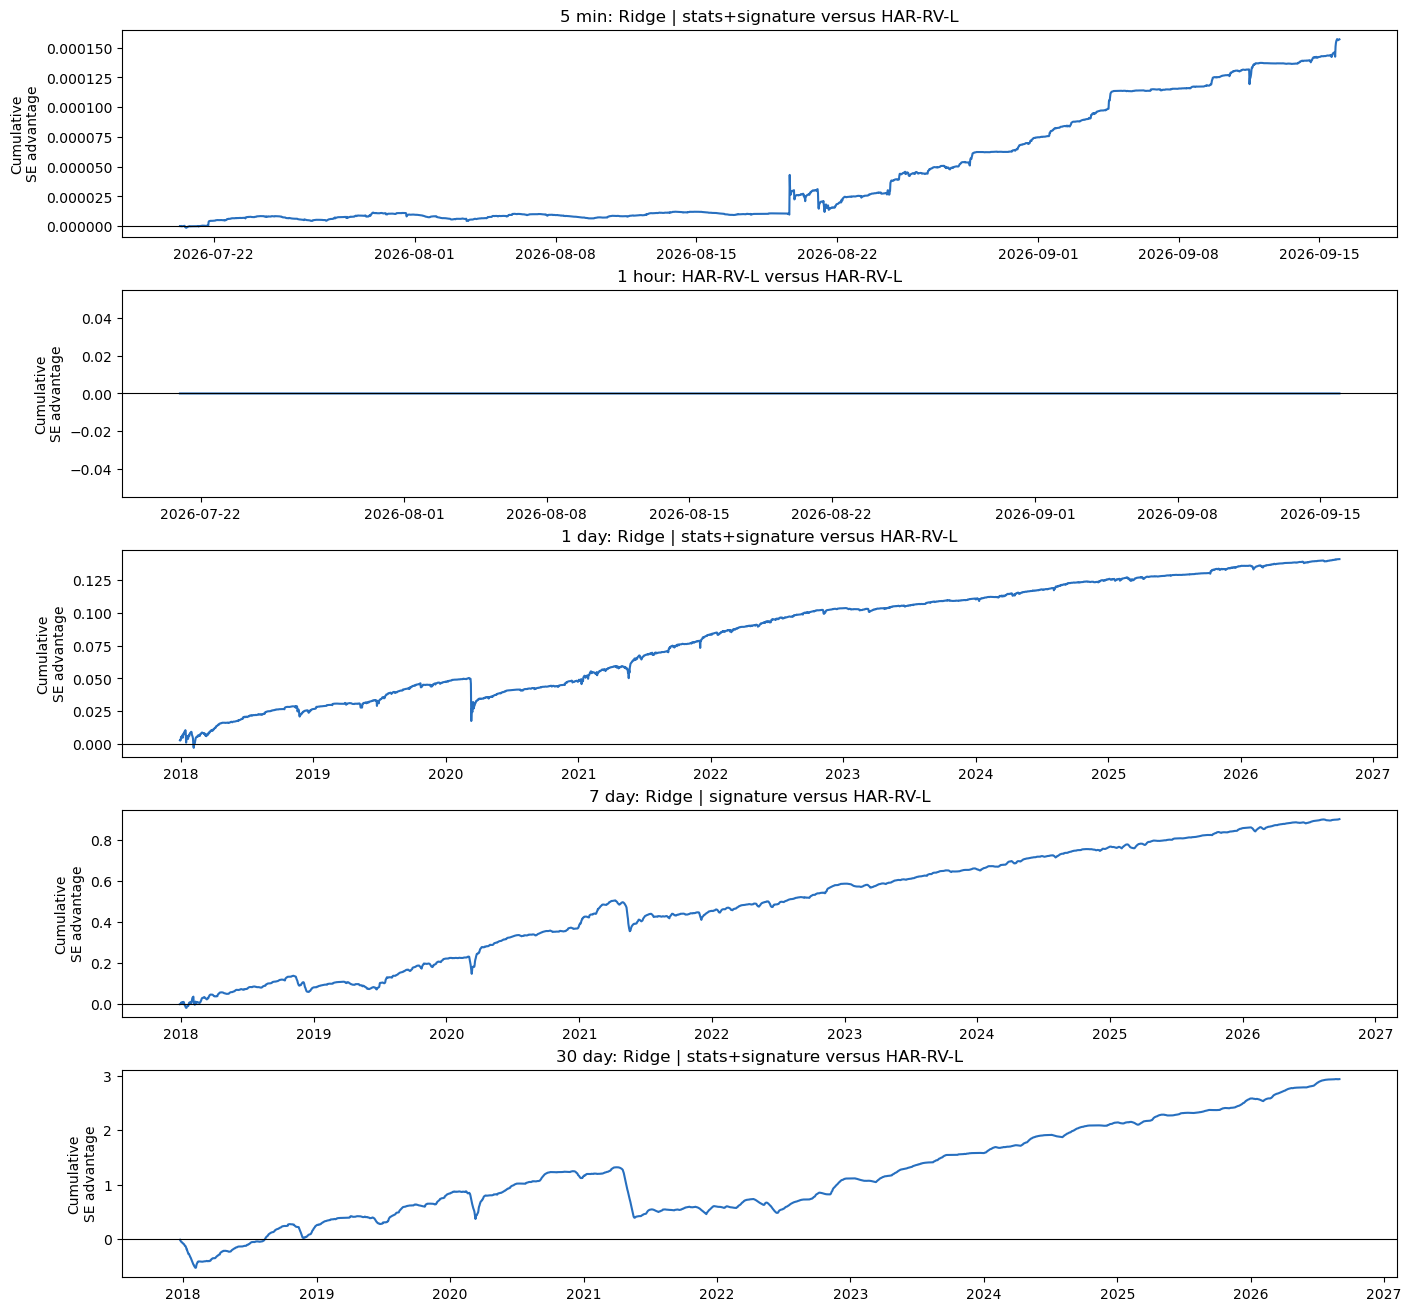

In [10]:
rp.plot_cumulative_advantage(res); plt.show()

### Calm vs stressed periods

Regimes are terciles of realized volatility in the out-of-sample target; descriptive only, never a model input.

/Users/mihikaghaisas/miniforge3/envs/test1/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


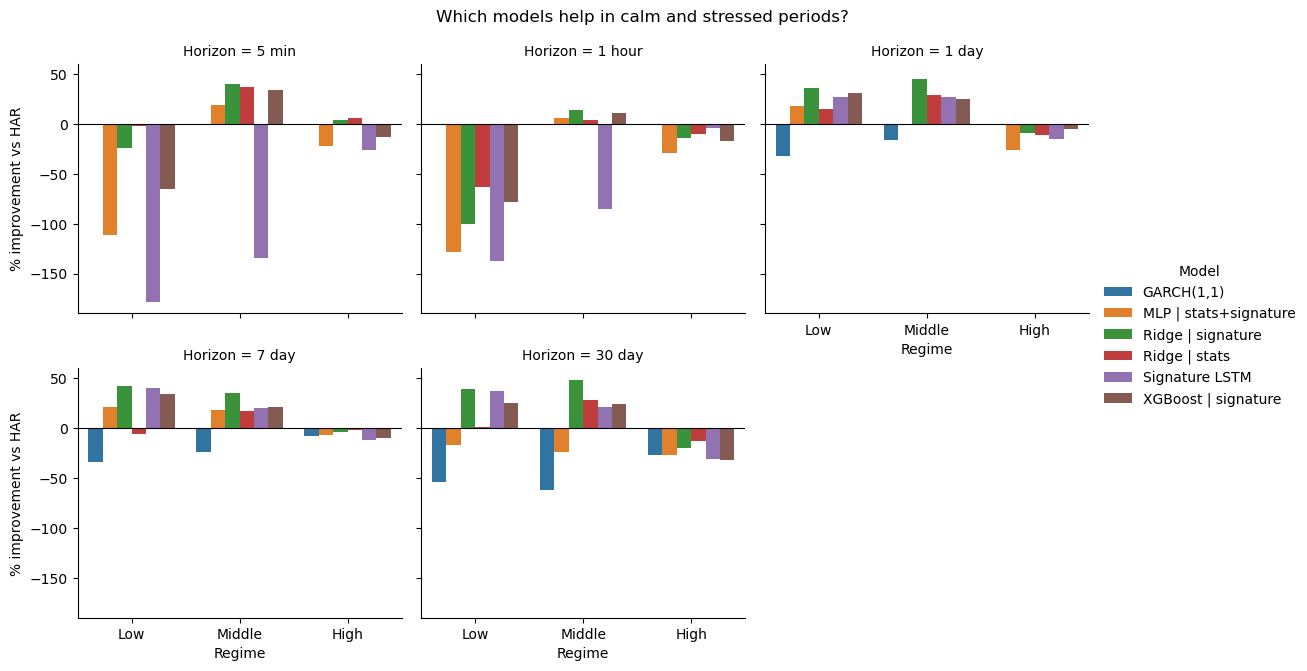

In [11]:
rp.plot_regimes(res); plt.show()

### What in the signature construction matters?

Ridge on signatures with the folds held fixed, so only the representation changes. Compared against a control in each panel: level 1 only, the raw path, price only. These are descriptive and are not used to pick the specification in the main table.

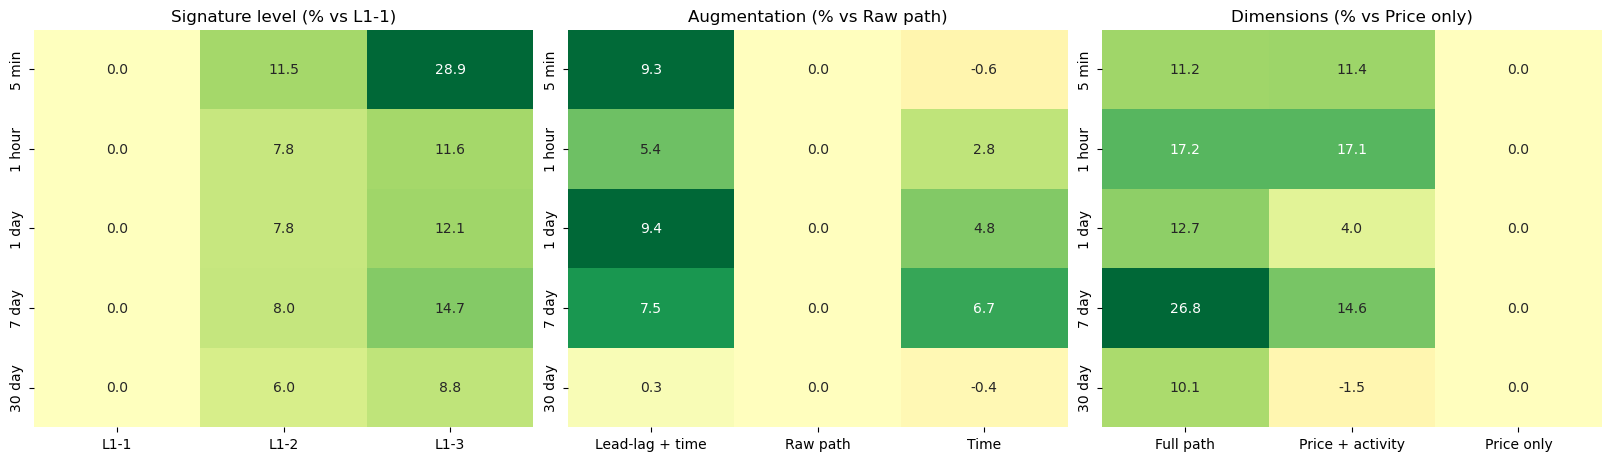

In [12]:
rp.plot_ablations(res); plt.show()

## 5. HMM anomaly flag

A 3-state Gaussian HMM, refit in each fold on data before the test block, gives a filtered probability of the stress (highest-volatility) state. Thresholded at 0.5 it is the 0/1 flag. It is added to the forecasts as extra columns (`+ flag` models) or as an extra signature path dimension (`+ stress dim`).

These cells need results produced with `use_flag=True`. A horizon already in `results/<run>/` is skipped on re-run, so use a new `output_dir` (or delete the horizon folders) to include the flag models.

In [ ]:
if res.flags.empty:
    print("No flag results in this run. Re-run with use_flag=True into a fresh output_dir.")
else:
    display(rp.flag_diagnostics_table(res).style.format(
        {"Share_flagged_train": "{:.1%}", "Share_flagged_test": "{:.1%}", "Mean_episode_rows": "{:.1f}",
         "Mean_vol_flagged": "{:.4g}", "Mean_vol_unflagged": "{:.4g}", "Vol_ratio_flagged_vs_not": "{:.2f}"}))

Check first that the flag is sensible: on a minority of the time, in coherent episodes, and with higher volatility while on.

In [ ]:
if not res.flags.empty:
    rp.plot_flag_timeline(res); plt.show()

### Does the flag improve the forecasts?

Each row compares a model with the same model plus the flag. `Pct_*` is the % RMSE change (positive = flag helps), overall and split by flagged / unflagged rows; `DM_p` tests the with-flag version against the original.

In [ ]:
if not res.flags.empty:
    display(rp.flag_effect_table(res).style.format(
        {c: "{:.1f}" for c in ["Pct_all", "Pct_flagged", "Pct_unflagged"]}
        | {c: "{:.4g}" for c in ["RMSE_base_all", "RMSE_flag_all", "RMSE_base_flagged", "RMSE_flag_flagged",
                                 "RMSE_base_unflagged", "RMSE_flag_unflagged"]}
        | {"DM_stat": "{:.2f}", "DM_p": "{:.3g}"}))

## 6. Save summary

In [13]:
summary.to_csv(f"{cfg.output_dir}/model_summary.csv", index=False)
print("saved", f"{cfg.output_dir}/model_summary.csv")

saved results/main/model_summary.csv
